# Introduction
Welcome to Lab 2, in this lab we will take our first steps into applying ML to satellite data, using landcover analysis as our primary goal.

As covered in Lecture 2, landcover classification is the quintessential remote sensing task in the civil sector. The LandSat programme was originally developed in large part to enable the USA to monitor landcover more easily for a range of agricultral, govermental and finacial problemsets. It remains a primary task for governments and companies around the world.

This is a pixel-wise ML task. We will apply two methods, both of which are available in GEE as ready-to-go algorithms. In this instance we are happy to go with built-in as it allows us to become familiar with an end-to-end GEE ML workflow without getting bogged down in technical detail. No need to re-invent the wheel unless you are going to the [moon](https://www.nasa.gov/feature/ames/artemis-moon-rover-s-wheels-are-ready-to-roll/).

Remember that this is a set of exercises and tutorials that escalate in difficulty. Always show your working and do not neccesarily expect to get full marks on everything.

Use the resources available to you outside of this material. I expect you to search for concepts or terms you do not understand and to look at the documentation of the code packages that we are using in the first instance of getting stuck.
_______________________________________________________________________________

# Set up

In [106]:
# Install libs if needed, note the --quiet option means a lot less annoying info than as Lab 1 when we did the same!
# !pip install geemap --quiet

In [3]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='geog761-dongwook') #<- Remember to change this to your own project's name!

In [4]:
# Import other libs
import geemap
import geopandas as gpd
import pandas as pd

# Define Area of Interest (AOI)

In [5]:
# Define area of interest (e.g., Wellington, NZ)
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map = geemap.Map(center=[-41.3, 174.75], zoom=10)
Map.addLayer(aoi, {}, 'AOI')

# Visualize on the map to check got it right... (always a good idea)
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

# Load and Cloud Mask Imagery from Earth Engine

In [8]:
# Set up your filter Sentinel-2 imagery
# A function that masks clouds in your S2 images via QA band
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
           qa.bitwiseAnd(cirrusBitMask).eq(0))
    # return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])
    return image.updateMask(mask).divide(10000)

# Now build the clean collection with selected bands
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi)
)

In [9]:
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2021-01-01', '2021-12-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
      .map(mask_s2_clouds)
      .median() #<- think about this step and what it is doing to your image when you build your single composite from the image collection
      .clip(aoi)
)

(1) What other mathematical [compositing](https://developers.google.com/earth-engine/guides/ic_composite_mosaic) approaches could you take when building your single image from the filtered image collection you create in the cell above? Hint: you currently are doing a 'median-composite'. (3 pts)

Other mathematical compositing approaches for building a single image from an image collection include:
 
1. **Mean composite** - Takes the average pixel value across all images in the collection, which can help reduce noise but may blur sharp features
 
2. **Maximum composite** - Selects the highest pixel value at each location, useful for highlighting peak values like vegetation indices or bright features
 
3. **Minimum composite** - Selects the lowest pixel value at each location, often used for atmospheric correction or shadow detection
 
4. **Mosaic composite** - Combines images based on their order in the collection (last image on top), useful when you want to prioritize more recent or higher quality images
 
5. **Quality mosaic** - Uses metadata quality bands to select the best pixel from each location based on quality scores
 
 Reference: [Google Earth Engine Compositing and Mosaicking Guide](https://developers.google.com/earth-engine/guides/ic_composite_mosaic)

In [10]:
# Set up the visualisation and then once again check it has worked, stacking layers in a sensible order
Map = geemap.Map(center=[-41.3, 174.75], zoom=11) #<- reset the map object to clear out other layers from earlier cells
Map.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'S2 RGB')
Map.addLayer(aoi, {'color': 'red'}, 'AOI')
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

________________________________________________________________________________

# Training data

We are going to train our data using the European Space Agency (ESA) world landcover map. Given that this is derived from satellite data our logic is at risk of becoming a little circular here. But as a training exercise it is a good way to have easy to access training data of the right size and type to apply to our image.

There are a wide range of landcover datasets in the GEE catalogue that you can use for this purpose:
*   https://developers.google.com/earth-engine/datasets/tags/landuse-landcover

First, we will load in the landcover map we will use to create our training dataset (https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100):



Next we need to use our landcover map to [sample](https://developers.google.com/earth-engine/apidocs/ee-image-sample) the Sentinel 2 image, associating each pixel of a given landcover with the spectral band values 'beneath' it.

In [11]:
# Define valid WorldCover classes (10 to 100, spaced by 10)
valid_classes = ee.List.sequence(10, 100, 10)

# Need to change this to sequential list to avoid the algs thiniing there are 99 classes rather than 9
remap_to = ee.List.sequence(1, 10)

# Load landcover map
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: create a new band with remapped values (10 → 1, ..., 100 → 10)
landcover_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')

(2) What year of data was this landcover map (accessed in the cell above) created on? (1 pt)

In [12]:
landcover.date()

The European Space Agency (ESA) WorldCover 10 m 2020 product provides a [global land cover map for 2020](https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100#:~:text=a%20global%20land%20cover%20map%20for%202020). we can also check through API `landcover.date()`


In [13]:
# Add landcover original and remapped as bands to Sentinel-2 image
training_data = s2.addBands(landcover_remapped)


Let's inspect the resulting training dataset and make sure that you understand what you have built here.

We are going to:
- Print the first few rows (client-side).
- Check the number of samples per class (server-side with reduceColumns).

This may take a little time to run as we request data both client and server side.

In [14]:
# Sample the image
bands = ['B2', 'B3', 'B4', 'B8']
sample = training_data.select(bands + ['Map_remapped']).sample(
    region=aoi,
    scale=10,
    numPixels=5000,
    seed=2,
    geometries=True)

# Print first 10 sample points (client-side)
first_10 = sample.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['Map_remapped']}, B2={props['B2']}, B3={props['B3']}, B4={props['B4']}, B8={props['B8']}")

# Count number of samples per class (server-side)
class_counts = sample.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['Map_remapped'])

print('\nClass distribution in sample:')
print(class_counts.getInfo())



First 10 training samples:
Sample 1: Class=8, B2=0.026799999177455902, B3=0.026499999687075615, B4=0.005799999926239252, B8=0.002899999963119626
Sample 2: Class=8, B2=0.039400000125169754, B3=0.028750000521540642, B4=0.0077333333902060986, B8=0.004800000227987766
Sample 3: Class=1, B2=0.01510000042617321, B3=0.03849999979138374, B4=0.02287999913096428, B8=0.23090000450611115
Sample 4: Class=8, B2=0.04749999940395355, B3=0.03200000151991844, B4=0.007666666526347399, B8=0.004550000187009573
Sample 5: Class=1, B2=0.011644444428384304, B3=0.02458333410322666, B4=0.018553845584392548, B8=0.2840000092983246
Sample 6: Class=5, B2=0.10279999673366547, B3=0.09380000084638596, B4=0.09399999678134918, B8=0.12139999866485596
Sample 7: Class=1, B2=0.025599999353289604, B3=0.049800001084804535, B4=0.03869999945163727, B8=0.3140000104904175
Sample 8: Class=8, B2=0.04417499899864197, B3=0.032229166477918625, B4=0.008299999870359898, B8=0.003800000064074993
Sample 9: Class=8, B2=0.03579999879002571, B

(3) What type of landcover is being sampled in sample number 2 of the dataset? Make sure your random seed is set to 2 in the sampling code so that you get the same answer as me. (1 pt)


**Answer** : It is Class 8 -> 80 , Permanent water bodies 

Sample 2: *Class=8*, B2=0.039400000125169754, B3=0.028750000521540642, B4=0.0077333333902060986, B8=0.004800000227987766  

[Map Class Table](https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100#bands)

| Value | Color | Description |
| :--- | :--- | :--- |
| 10 | 006400 | Tree cover |
| 20 | ffbb22 | Shrubland |
| 30 | ffff4c | Grassland |
| 40 | f096ff | Cropland |
| 50 | fa0000 | Built up |
| 60 | b4b4b4 | Bare sparse vegetation |
| 70 | f0f0f0 | Snow and ice |
| 80 | 0064c8 | Permanent water bodies |
| 90 | 0096a0 | Herbaceous wetland |
| 95 | 00cf75 | Mangroves |
| 100 | fae6a0 | Moss and lichen |




We are now ready to start machine learning on classifying the landcover of Wellington!
________________________________________________________________________________

# Random Forest Classification for Landcover
Let us do machine learning properly and first apply a 70/20/10 split that allows us to produce some accuracy statistics.

In [15]:
# Add random column
sample = sample.randomColumn('random')

# Split
train = sample.filter(ee.Filter.lt('random', 0.7))
valid = sample.filter(ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9)))
test = sample.filter(ee.Filter.gte('random', 0.9))

Our next task is to set up a classifier object, followed by applying it to the image using the .classify operator. This operator hides a LOT of behind the scenes plumbing from Google.

We use the [GEE Random Forest](https://developers.google.com/earth-engine/apidocs/ee-classifier-smilerandomforest) model that they have pre-built for us. Specifying the number of trees to use is the only variable we must set. Othe variables are available, read the docs!

In [16]:
# Train the RF model
classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='Map_remapped',
    inputProperties=bands)

With the model trained, we just apply it simply using the '.classify' operator.

In [17]:
# Classify image
classified = s2.select(bands).classify(classifier)

Let's visualize what we have just made!

In [18]:
# Classified image viz, fresh set up again to make sure we have exactly what we want displayed.
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(classified.randomVisualizer(), {}, 'Classified')
Map.addLayer(landcover_remapped.randomVisualizer(), {} ,'ESA Landcover')
Map

Map(center=[-41.30004624634492, 174.74999999999935], controls=(WidgetControl(options=['position', 'transparent…

(4) Look at the ESA landcover map and our resulting random forest classified Sentinel 2 image map. How are they different and what might be some causes of this difference? (5 pts)


**Differences**

The ESA map looks more continous, larger, smoother patches of tree cover, grassland and water, while RF classified s2 map looks noiser with more gragmented class boundaries. 

**Causes**

1. Different Years - ESA WorldCover(landcover) is 2020 and Sentinel-2(classified) is 2021, so real land-cover might be different
2. Limited Training Inputs - Classified sentinel-2 uses only 4 bands(B2,B3,B4,B8), so similar spectra are hard to seperate. 
3. Different methods - While WorldCover(ESA) is a global, multi-sensor product, the classifed sentinel-2 imagery relies on pixel-based Random Forest classification using a single median composite. 




Finally, we will apply our test data split and produce the [summary statistics](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall) that we need to make smart choices about our training approach.

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd


# Validate
validated = valid.classify(classifier, 'predicted')

# Function to export data for confusion matrix
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

# Get predicted vs actual from validation set
y_true, y_pred = fc_to_lists(validated, 'Map_remapped', 'predicted')

# Labels for original classes
label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
label_names = [label_map[i + 1] for i in range(10)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 11)))
report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in label_names])

# Pretty-print
print("Confusion Matrix:")
print(pd.DataFrame(cm, index=[f"Actual {l}" for l in label_names],
                       columns=[f"Pred {l}" for l in label_names]))


Confusion Matrix:
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       207        0       23        0        7        0        0   
Actual 20         0        0        1        0        0        0        0   
Actual 30        46        0      129        0        5        0        0   
Actual 40         0        0        0        0        0        0        0   
Actual 50         2        0        5        0       28        2        0   
Actual 60         0        0        2        0        2        1        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        2        0        0   
Actual 90         1        0        0        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0  
Actual 30  

In [20]:
print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

          10       0.81      0.87      0.84       237
          20       0.00      0.00      0.00         1
          30       0.81      0.71      0.76       181
          40       0.00      0.00      0.00         0
          50       0.64      0.76      0.69        37
          60       0.33      0.17      0.22         6
          70       0.00      0.00      0.00         0
          80       1.00      1.00      1.00       531
          90       0.00      0.00      0.00         1
         100       0.00      0.00      0.00         0

    accuracy                           0.90       994
   macro avg       0.36      0.35      0.35       994
weighted avg       0.90      0.90      0.90       994



## Other Approach

In [21]:
order = sample.aggregate_array('Map_remapped').distinct().sort()
validate_matrix = validated.errorMatrix('Map_remapped', 'predicted',order)

In [22]:

print("Confusion Matrix:")
print(pd.DataFrame(validate_matrix.getInfo(), index=[f"Actual {l*10}" for l in order.getInfo()],
                       columns=[f"Pred {l*10}" for l in order.getInfo()]))

Confusion Matrix:
           Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 80  \
Actual 10      207        0       23        0        7        0        0   
Actual 20        0        0        1        0        0        0        0   
Actual 30       46        0      129        0        5        0        1   
Actual 40        0        0        0        0        0        0        0   
Actual 50        2        0        5        0       28        2        0   
Actual 60        0        0        2        0        2        1        1   
Actual 80        0        0        0        0        2        0      529   
Actual 90        1        0        0        0        0        0        0   

           Pred 90  
Actual 10        0  
Actual 20        0  
Actual 30        0  
Actual 40        0  
Actual 50        0  
Actual 60        0  
Actual 80        0  
Actual 90        0  


In [23]:
print('Overall accuracy:', validate_matrix.accuracy().getInfo())

Overall accuracy: 0.8993963782696177


(5) Exercise: modify the code so that you feed into your random forest classifier that has been trained on 2020 data, on other years of Sentinel 2 data than 2020. Produce a publication quality figure that presents the following:
*   Landcover maps of Wellington for 2018, 2022 and 2024
*   The Test accuracy averages of the RF classifier for 2020.
*   Include a sentence in your figure caption that explains why you cannot state the accuracy of the classifier for years other than 2020.

(15 pts)



## Exercise 5: Apply 2020-trained RF to 2018, 2022, 2024

Classify Wellington Sentinel-2 composites for other years with the same RF classifier, then draw a publication-quality multi-panel figure (Lab 1 subplot style).

In [24]:
# Predict Test Dataset and Calculate Accuracy
tested = test.classify(classifier, 'predicted')
test_matrix = tested.errorMatrix('Map_remapped', 'predicted',order)
rf_test_accuracy_2020 = test_matrix.accuracy().getInfo()

In [25]:
# Years to classify with the RF model trained on ESA WorldCover 2020 labels
years = [2018, 2022, 2024]
bands = ['B2', 'B3', 'B4', 'B8']
classified_maps = {}

# ESA WorldCover-style palette for remapped classes 1–10
class_palette = [
    '006400',  # 1 Tree cover
    'ffbb22',  # 2 Shrubland
    'ffff4c',  # 3 Grassland
    'f096ff',  # 4 Cropland
    'fa0000',  # 5 Built up
    'b4b4b4',  # 6 Bare / sparse vegetation
    'f0f0f0',  # 7 Snow and ice
    '0064c8',  # 8 Permanent water bodies
    '0096a0',  # 9 Herbaceous wetland
    'fae6a0',  # 10 Moss and lichen (WorldCover 100)
]

vis_params = {'min': 1, 'max': 10, 'palette': class_palette}

# 2020 RF test accuracy from earlier cell
print(f'RF test accuracy (2020 labels / validation split): {rf_test_accuracy_2020:.3f}')

RF test accuracy (2020 labels / validation split): 0.905


In [26]:
def get_sentinel2_for_year(year, aoi,bands):
    """Median cloud-masked S2 SR composite for one calendar year (same prep as training)."""
    
    filtered_img = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
        .map(mask_s2_clouds)
    )
    # extract date from the first image in the collection
    img_date = filtered_img.first().getInfo()['properties']['system:index'][:8]
    img_date_formatted = img_date[:4] + '-' + img_date[4:6] + '-' + img_date[6:]
    # median composite
    selected_img = filtered_img.median().clip(aoi).select(bands)
    
    return img_date_formatted,selected_img

# Apply the 2020-trained RF classifier to each year
for year in years:
    s2_date, s2_collection = get_sentinel2_for_year(year, aoi,bands)
    classified_maps[year] = {}
    classified_maps[year]['classify'] = s2_collection.classify(classifier)
    classified_maps[year]['img_date'] = s2_date
    print(f'Classified {year}')

Classified 2018
Classified 2022
Classified 2024


### Publication-quality figure

Use the same approach as Lab 1.

In [27]:
import tempfile
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches

# Class labels for legend (remapped 1–10 ↔ WorldCover codes)
class_labels = {
    1: 'Tree cover',
    2: 'Shrubland',
    3: 'Grassland',
    4: 'Cropland',
    5: 'Built up',
    6: 'Bare / sparse',
    7: 'Snow / ice',
    8: 'Water',
    9: 'Wetland',
    10: 'Moss / lichen',
}

def get_bounds_coords(bounds):
    coords = bounds.coordinates().getInfo()[0]
    lons = [pt[0] for pt in coords]
    lats = [pt[1] for pt in coords]
    return min(lons), max(lons), min(lats), max(lats)

xmin, xmax, ymin, ymax = get_bounds_coords(aoi)

def classified_thumb(img):
    """RGB thumbnail of a classified image."""
    return img.visualize(**vis_params).getThumbURL({
        'dimensions': 800,
        'region': aoi,
        'format': 'png',
    })

# Fetch thumbnails for each year
thumb_urls = {year: classified_thumb(classified_maps[year]['classify']) for year in years}


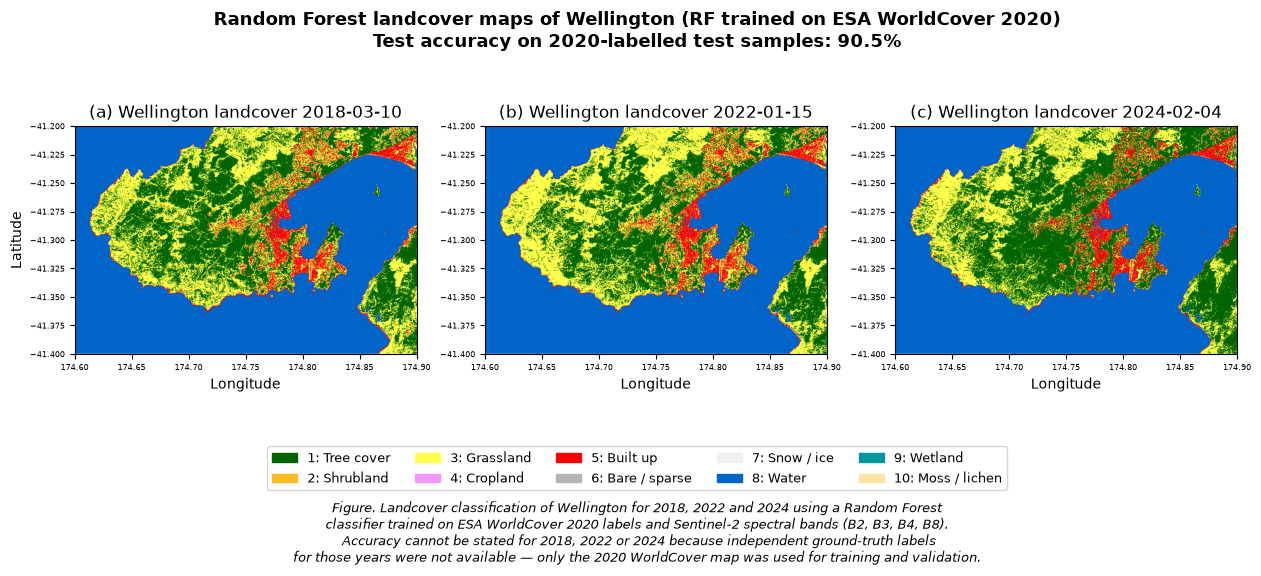

In [28]:

# --- Figure layout: 1×3 maps (Lab 1: fig + axes / gridspec) ---
fig = plt.figure(figsize=(15, 6.5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.2)
axes = [fig.add_subplot(gs[0, i]) for i in range(3)]

for ax, year in zip(axes, years):
    with tempfile.NamedTemporaryFile(suffix='.png') as f:
        urllib.request.urlretrieve(thumb_urls[year], f.name)
        img = mpimg.imread(f.name)
        ax.imshow(img, extent=[xmin, xmax, ymin, ymax])
    ax.set_title(f'({chr(97 + years.index(year))}) Wellington landcover {classified_maps[year]["img_date"]}', fontsize=12)
    ax.set_xlabel('Longitude', fontsize=10)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.tick_params(labelsize=6)

axes[0].set_ylabel('Latitude', fontsize=10)

# Shared Bottom legend
legend_patches = [
    mpatches.Patch(color=f'#{class_palette[i]}', label=f'{i+1}: {class_labels[i+1]}')
    for i in range(10)
]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=5,
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, 0.1),
)


fig.suptitle(
    'Random Forest landcover maps of Wellington (RF trained on ESA WorldCover 2020)\n'
    f'Test accuracy on 2020-labelled test samples: {rf_test_accuracy_2020:.1%}',
    fontsize=13,
    fontweight='bold',
    y=0.85
)

# Caption: accuracy only for 2020 — no independent labels for other years
fig.text(
    0.5, 0.00,
    'Figure. Landcover classification of Wellington for 2018, 2022 and 2024 using a Random Forest\n'
    'classifier trained on ESA WorldCover 2020 labels and Sentinel-2 spectral bands (B2, B3, B4, B8).\n '
    'Accuracy cannot be stated for 2018, 2022 or 2024 because independent ground-truth labels\n'
    'for those years were not available — only the 2020 WorldCover map was used for training and validation.',
    ha='center',
    fontsize=9,
    style='italic',
)

plt.tight_layout()
fig.savefig('figures/lab2_wellington_rf_landcover_2018_2022_2024.png', dpi=300, bbox_inches='tight')
plt.show()

_______________________________________________________________________________

# SVMs Applied to Satellite Data

In [29]:
# # Define and train the SVM classifier
class_property = 'Map_remapped'
svm = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=train,
    classProperty=class_property,
    inputProperties=bands
)

# Classify validation and test sets
val_classified = valid.classify(svm)
test_classified = test.classify(svm)

y_true, y_pred = fc_to_lists(val_classified, 'Map_remapped', 'classification')

# Evaluate test performance
test_matrix = val_classified.errorMatrix(class_property, 'classification',order)


print("Confusion Matrix:")
print(pd.DataFrame(test_matrix.getInfo(), index=[f"Actual {l}" for l in order.getInfo()],
                       columns=[f"Pred {l}" for l in order.getInfo()]))


report = classification_report(y_true, y_pred, labels=list(range(1, 11)), target_names=[str(l) for l in order.getInfo()])
print("\nClassification Report:")
print(report)

Confusion Matrix:
          Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 8  Pred 9
Actual 1     210       0      23       0       4       0       0       0
Actual 2       1       0       0       0       0       0       0       0
Actual 3      52       0     125       0       3       0       1       0
Actual 4       0       0       0       0       0       0       0       0
Actual 5       4       0       6       0      27       0       0       0
Actual 6       0       0       3       0       3       0       0       0
Actual 8       0       0       0       0       2       0     529       0
Actual 9       1       0       0       0       0       0       0       0

Classification Report:
              precision    recall  f1-score   support

           1       0.78      0.89      0.83       237
           2       0.00      0.00      0.00         1
           3       0.80      0.69      0.74       181
           4       0.00      0.00      0.00         0
           5       0.69      0

(6) Exercise: train an SVM model using the Landcare NZ 2018 landcover database record for the region. Producing a landcover map of Great Barrier (Aotea) Island for 2018 (based off the Austral summer of 18/19 S2).

Your map should be presented at a publication quality level with all the usual map components (scale, legend, north arrow, data attribution).

You will need to provide performance statistics of the model within your figure.

*   Here you can access the landcover database: https://lris.scinfo.org.nz/layer/104400-lcdb-v50-land-cover-database-version-50-mainland-new-zealand/. You will need to explore for yourself how to extract this data and then upload it to colab, then how to plug it into the SVM algorithim. I have provided some starter code below.

An intial workflow to get the data into the state you need it in to then use it as training data might look like:
- Download the ZIP manually from their browser, having set your area of interest and used the 'Export' tool top right.
- Upload it to Colab.
- Unzip it and load with GeoPandas.
(25 pts)



## Exercise 6: SVM Classification of Landcover


**HISTORY**
1. Baseline : Accuracy(0.5)+ macro F1 (0.09) , Random Sampling + numPixels:5000 (1455 samples)
2. Run 1 : Accuracy(0.32), Stratified Sampling + 300 numPoints
3. Run 2 : Accuracy(0.44), Run1 + Add more bands(features), Weak on spectrally similar woody/grass classes
4. Run 3 : Accuracy(0.52), Run2 + Add 'NDVI', 'NDWI', 'NBR', 'NDMI', 'EVI', 'Class_2018'
5. Run 4 : Accuracy(0.45), Run1 + only 'NDVI', 'NDWI', 'NBR', 'NDMI', 'EVI' indices

In [459]:
# Code to get you started
import zipfile
import geopandas as gpd

# Upload the ZIP manually using the Colab UI
# from google.colab import files
# uploaded = files.upload()  # <- Expects a ZIP

# Unzip
with zipfile.ZipFile("datasets/lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP.zip", 'r') as zip_ref: #<- Check file names
    zip_ref.extractall("datasets/lcdb")



FileNotFoundError: [Errno 2] No such file or directory: 'datasets/lris-lcdb-v50-land-cover-database-version-50-mainland-new-zealand-SHP.zip'

In [30]:

# Read shapefile
gdf = gpd.read_file("datasets/lcdb/lcdb-v50-land-cover-database-version-50-mainland-new-zealand.shp") #<- Check file names


In [31]:
display(gdf.head(3))

,Name_2018,Name_2012,Name_2008,Name_2001,Name_1996,Class_2018,Class_2012,Class_2008,Class_2001,Class_1996,...,Wetland_96,Onshore_18,Onshore_12,Onshore_08,Onshore_01,Onshore_96,EditAuthor,EditDate,LCDB_UID,geometry
0,Gravel or Rock,Gravel or Rock,Gravel or Rock,Gravel or Rock,Gravel or Rock,16,16,16,16,16,...,no,yes,yes,yes,yes,yes,Landcare Research,2004-06-30,lcdb2000021454,"POLYGON ((1339167.745 5005724.309, 1339080.897..."
1,Low Producing Grassland,Low Producing Grassland,Low Producing Grassland,Low Producing Grassland,Low Producing Grassland,41,41,41,41,41,...,no,yes,yes,yes,yes,yes,Terralink,2004-06-30,lcdb2000069669,"POLYGON ((1333203.873 5130136.165, 1333144.138..."
2,Broadleaved Indigenous Hardwoods,Broadleaved Indigenous Hardwoods,Broadleaved Indigenous Hardwoods,Broadleaved Indigenous Hardwoods,Broadleaved Indigenous Hardwoods,54,54,54,54,54,...,no,yes,yes,yes,yes,yes,Landcare Research,2011-06-30,lcdb1000126743,"POLYGON ((1722346.367 6070406.526, 1722327.668..."


### 1. Fitering out 2018 landcover data

In [32]:

columns = ['Name_2018','Class_2018','Wetland_18','Onshore_18','geometry']
gdf_cleaned = gdf[columns]
gdf_cleaned.to_crs(epsg=4326, inplace=True)  #Convert to EPSG 4326
display(gdf_cleaned.head(3))


,Name_2018,Class_2018,Wetland_18,Onshore_18,geometry
0,Gravel or Rock,16,no,yes,"POLYGON ((169.68748 -45.05388, 169.68635 -45.0..."
1,Low Producing Grassland,41,no,yes,"POLYGON ((169.67607 -43.93354, 169.67532 -43.9..."
2,Broadleaved Indigenous Hardwoods,54,no,yes,"POLYGON ((174.34901 -35.50238, 174.34881 -35.5..."


### 2. Get Sentinel-2 data for 2018

In [33]:

# Producing a landcover map of Great Barrier (Aotea) Island for 2018 
aoi = ee.Geometry.Rectangle([175.28, -36.35, 175.55, -36.02])

# baseline bands
base_bands = ['B2', 'B3', 'B4', 'B8']

# feature engineering(bands)
additional_bands = [ 'B5', 'B6', 'B7', 'B8A', 'B11', 'B12']
bands = base_bands + additional_bands

# Resuse sentinel-2 extraction function from exercise 5
s2_date, s2_clipped = get_sentinel2_for_year(2018, aoi, bands)

# Add indices to the Sentinel-2 image, for more accurate classification
def add_indices(img):
    ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndwi = img.normalizedDifference(['B3', 'B8']).rename('NDWI')
    nbr  = img.normalizedDifference(['B8', 'B12']).rename('NBR')
    ndmi = img.normalizedDifference(['B8', 'B11']).rename('NDMI')
    evi = img.expression(
        '2.5*((NIR-RED)/(NIR+6*RED-7.5*BLUE+1))',
        {'NIR': img.select('B8'), 'RED': img.select('B4'), 'BLUE': img.select('B2')}
    ).rename('EVI')
    return img.addBands([ndvi, ndwi, nbr, ndmi, evi])

s2_clipped = add_indices(s2_clipped)

In [34]:
Map = geemap.Map(center=[-36.1953, 175.4372], zoom=10)
Map.addLayer(aoi, {}, 'AOI')
Map.addLayer(s2_clipped.select(base_bands), {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.2}, 'Sentinel-2 RGB')
# Visualize on the map to check got it right... (always a good idea)
Map

Map(center=[-36.1953, 175.4372], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

### 3. Clip Landcover dataset

In [35]:
from shapely.geometry import box


# Convert Earth Engine geometry to shapely geometry for clipping
# Get the coordinates from the Earth Engine geometry
minx, miny = 175.30, -36.35
maxx, maxy = 175.55, -36.10

# Create the bounding box geometry
bbox_polygon = box(minx, miny, maxx, maxy)

# 3. Clip the GeoDataFrame
gdf_clipped = gdf_cleaned.clip(bbox_polygon)

# Check the result
display(gdf_clipped.head())

,Name_2018,Class_2018,Wetland_18,Onshore_18,geometry
386340,Sand or Gravel,10,no,yes,"POLYGON ((175.30228 -36.23857, 175.30192 -36.2..."
154815,Low Producing Grassland,41,no,yes,"POLYGON ((175.30191 -36.2315, 175.30218 -36.23..."
212965,Manuka and/or Kanuka,52,no,yes,"POLYGON ((175.30717 -36.23287, 175.30722 -36.2..."
315994,Manuka and/or Kanuka,52,no,yes,"POLYGON ((175.302 -36.23397, 175.30177 -36.233..."
234868,Indigenous Forest,69,no,yes,"POLYGON ((175.4509 -36.30519, 175.45119 -36.30..."


### 4. Preparing Training Data

In [40]:


# Convert the GeoDataFrame to Earth Engine FeatureCollection using geemap
landcover_fc = geemap.gdf_to_ee(gdf_clipped)

# Create a raster from the landcover polygons using the 'Class' field
landcover_raster = landcover_fc.reduceToImage(
    properties=['Class_2018'],
    reducer=ee.Reducer.first()
).rename('Class_2018')

# Add the landcover raster as a band to the Sentinel-2 image
training_data = s2_clipped.addBands(landcover_raster)

print("Added landcover data as 'Class_2018' band to Sentinel-2 image")
print("Available bands:", training_data.bandNames().getInfo())

Added landcover data as 'Class_2018' band to Sentinel-2 image
Available bands: ['B2', 'B3', 'B4', 'B8', 'B5', 'B6', 'B7', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'NBR', 'NDMI', 'EVI', 'Class_2018']


In [41]:
feature_bands = bands + ['NDVI', 'NDWI', 'NBR', 'NDMI', 'EVI']

# Baseline sampling 
# ex6_sample = training_data.select(bands + ['Class_2018']).sample( 
#     region=aoi,
#     scale=10,
#     numPixels=5000,
#     seed=2,
#     geometries=True)

# use stratifiedSampling for balanced sampling
ex6_sample = training_data.select(feature_bands + ['Class_2018']).stratifiedSample(
    numPoints = 300,  # increase number of samples to prevent overfitting, initial : 100 with 2134 samples
    classBand='Class_2018',
    region=aoi,
    scale=10,
    seed=2,
    geometries=True)

# Print first 10 sample points (client-side)
ex6_first_10 = ex6_sample.limit(10).getInfo()

print('\nFirst 10 training samples:')
for i, feature in enumerate(ex6_first_10['features']):
    props = feature['properties']
    print(f"Sample {i+1}: Class={props['Class_2018']}, B2={props.get('B2'):.2f}, B3={props.get('B3'):.2f}, B    4={props.get('B4'):.2f}, B8={props.get('B8'):.2f}, \
        NDVI={props.get('NDVI'):.2f}, NDWI={props.get('NDWI'):.2f}, NBR={props.get('NBR'):.2f}, NDMI={props.get('NDMI'):.2f}, EVI={props.get('EVI'):.2f}")

# Count number of samples per class (server-side)
ex6_class_counts = ex6_sample.reduceColumns(
    reducer=ee.Reducer.frequencyHistogram(),
    selectors=['Class_2018'])

print('\nClass distribution in sample:')
print(ex6_class_counts.getInfo())


First 10 training samples:
Sample 1: Class=1, B2=0.02, B3=0.03, B    4=0.02, B8=0.17,         NDVI=0.80, NDWI=-0.73, NBR=0.43, NDMI=0.15, EVI=0.33
Sample 2: Class=1, B2=0.04, B3=0.07, B    4=0.04, B8=0.41,         NDVI=0.82, NDWI=-0.70, NBR=0.63, NDMI=0.39, EVI=0.67
Sample 3: Class=1, B2=0.03, B3=0.05, B    4=0.05, B8=0.15,         NDVI=0.51, NDWI=-0.51, NBR=0.36, NDMI=0.14, EVI=0.20
Sample 4: Class=1, B2=0.06, B3=0.10, B    4=0.07, B8=0.39,         NDVI=0.70, NDWI=-0.60, NBR=0.52, NDMI=0.28, EVI=0.60
Sample 5: Class=1, B2=0.02, B3=0.04, B    4=0.04, B8=0.19,         NDVI=0.68, NDWI=-0.65, NBR=0.30, NDMI=0.11, EVI=0.31
Sample 6: Class=1, B2=0.03, B3=0.04, B    4=0.02, B8=0.03,         NDVI=0.21, NDWI=0.13, NBR=0.23, NDMI=0.02, EVI=0.03
Sample 7: Class=1, B2=0.03, B3=0.06, B    4=0.03, B8=0.41,         NDVI=0.87, NDWI=-0.75, NBR=0.68, NDMI=0.42, EVI=0.70
Sample 8: Class=1, B2=0.04, B3=0.06, B    4=0.05, B8=0.17,         NDVI=0.52, NDWI=-0.50, NBR=0.38, NDMI=0.22, EVI=0.25
Sample 9: Cla

### 4. Split the training dataset to Train and Test
We only use Train/Test dataset , because we will not tune model

In [42]:
# Add random column
ex6_sample = ex6_sample.randomColumn('random',seed=2)

# Split
ex6_train = ex6_sample.filter(ee.Filter.lt('random', 0.8))
ex6_test = ex6_sample.filter(ee.Filter.gte('random', 0.8))

In [43]:
# number of train and test samples
print(f"Number of total samples: {ex6_sample.size().getInfo()}")
print(f"Number of train samples: {ex6_train.size().getInfo()}")
print(f"Number of test samples: {ex6_test.size().getInfo()}")


Number of total samples: 5843
Number of train samples: 4749
Number of test samples: 1094


### 5. Training the SVM Model

In [44]:
# # Define and train the SVM classifier
class_property = 'Class_2018'
ex6_svm = ee.Classifier.libsvm(kernelType='RBF', gamma=0.5, cost=10).train(
    features=ex6_train,
    classProperty=class_property,
    inputProperties=feature_bands
)

# Classify validation and test sets
ex6_test_classified = ex6_test.classify(ex6_svm)



In [45]:
# return true and predicted values
y_true, y_pred = fc_to_lists(ex6_test_classified, 'Class_2018', 'classification')
assert len(y_true) == len(y_pred), "y_true and y_pred have different lengths"


### 6. Evaludate the Performance of the SVM Model


In [46]:
# order of classes in test dataset. I don't want to print all of them, which is not exist in the test dataset
ex6_order = ex6_test.aggregate_array('Class_2018').distinct().sort() 

# use errorMatrix in google earth engine
ex6_test_matrix = ex6_test_classified.errorMatrix(class_property, 'classification',ex6_order)


In [47]:
# From lcdb-classes-at-version5.pdf (short names)
LCDB_NAMES = {
    0: 'Not land',
    1: 'Built-up Area',
    2: 'Urban Parkland/Open Space',
    5: 'Transport Infrastructure',
    6: 'Surface Mine or Dump',
    10: 'Sand or Gravel',
    12: 'Landslide',
    14: 'Permanent Snow and Ice',
    15: 'Alpine Grass/Herbfield',
    16: 'Gravel or Rock',
    20: 'Lake or Pond',
    21: 'River',
    22: 'Estuarine Open Water',
    30: 'Short-rotation Cropland',
    33: 'Orchards/Vineyards/Perennial Crops',
    40: 'High Producing Exotic Grassland',
    41: 'Low Producing Grassland',
    43: 'Tall Tussock Grassland',
    44: 'Depleted Grassland',
    45: 'Herbaceous Freshwater Vegetation',
    46: 'Herbaceous Saline Vegetation',
    47: 'Flaxland',
    50: 'Fernland',
    51: 'Gorse and/or Broom',
    52: 'Manuka and/or Kanuka',
    54: 'Broadleaved Indigenous Hardwoods',
    55: 'Sub Alpine Shrubland',
    56: 'Mixed Exotic Shrubland',
    58: 'Matagouri or Grey Scrub',
    64: 'Forest - Harvested',
    68: 'Deciduous Hardwoods',
    69: 'Indigenous Forest',
    71: 'Mangrove',
    80: 'Exotic Forest',
}

# List up only exist labels
labels = ex6_order.getInfo() 
names = [LCDB_NAMES.get(int(l), str(l))+'('+str(l)+')' for l in labels] 

print("Confusion Matrix:")
display(pd.DataFrame(ex6_test_matrix.getInfo(), index=names, columns=names))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=labels, target_names=names))

Confusion Matrix:


,Built-up Area(1),Urban Parkland/Open Space(2),Transport Infrastructure(5),Surface Mine or Dump(6),Sand or Gravel(10),Landslide(12),Gravel or Rock(16),Lake or Pond(20),River(21),Estuarine Open Water(22),...,Low Producing Grassland(41),Herbaceous Freshwater Vegetation(45),Herbaceous Saline Vegetation(46),Gorse and/or Broom(51),Manuka and/or Kanuka(52),Broadleaved Indigenous Hardwoods(54),Forest - Harvested(64),Indigenous Forest(69),70(70),Mangrove(71)
Built-up Area(1),18,6,4,1,1,0,0,0,1,0,...,0,1,1,2,1,1,0,0,0,1
Urban Parkland/Open Space(2),1,35,6,0,1,0,0,0,0,0,...,0,1,0,1,0,0,1,0,0,0
Transport Infrastructure(5),0,1,37,0,0,0,0,0,0,0,...,1,2,1,1,1,0,1,0,0,0
Surface Mine or Dump(6),3,0,1,18,5,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
Sand or Gravel(10),11,1,5,4,25,0,0,0,4,0,...,0,0,1,1,4,0,2,1,0,0
Landslide(12),0,0,0,0,5,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8
Gravel or Rock(16),0,0,0,1,0,0,24,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Lake or Pond(20),0,0,0,0,0,0,0,5,2,0,...,0,2,1,0,1,0,0,0,1,0
River(21),0,0,0,2,0,0,5,0,32,9,...,0,2,4,0,0,0,0,0,0,2
Estuarine Open Water(22),0,0,0,0,0,0,1,0,3,50,...,0,0,0,0,0,0,0,0,4,0



Classification Report:
                                        precision    recall  f1-score   support

                      Built-up Area(1)       0.35      0.36      0.36        50
          Urban Parkland/Open Space(2)       0.51      0.60      0.55        58
           Transport Infrastructure(5)       0.41      0.80      0.54        46
               Surface Mine or Dump(6)       0.67      0.62      0.64        29
                    Sand or Gravel(10)       0.57      0.42      0.49        59
                         Landslide(12)       1.00      0.13      0.24        15
                    Gravel or Rock(16)       0.80      0.96      0.87        25
                      Lake or Pond(20)       1.00      0.42      0.59        12
                             River(21)       0.62      0.57      0.59        56
              Estuarine Open Water(22)       0.81      0.86      0.83        58
Orchards/Vineyards/Perennial Crops(33)       0.37      0.56      0.45        45
   High Produci